# Imports

In [1]:
import os
import sys
from time import time
import cv2
import numpy as np
from tqdm import tqdm
from glob import glob
import matplotlib.pyplot as plt
import math

import albumentations as A
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.losses import binary_crossentropy

from tensorflow.keras.models import *
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger


# Loading Dataset 

In [2]:
imgs_dir='../input/nfbs-dataset-skull-stripped-segmentation/NFBS'
all_dirs = glob (f'{imgs_dir}/*')
all_dirs.sort()
print(len (all_dirs))

23999


In [3]:
def shuffle_split (all_dirs, val_pct = 0.15, seed = 99):
    """ shuffling dataset with random state and split to train and valid """
    n_val = int (len (all_dirs) * val_pct)
    np.random.seed (seed)
    idx = np.random.permutation (len (all_dirs))
    all_dirs = np.array (all_dirs) [idx]
    return all_dirs [n_val:], all_dirs [:n_val]
# all_dirs=all_dirs[:1000]
train_dirs, valid_dirs = shuffle_split (all_dirs, seed = 1)
len(valid_dirs), len(train_dirs)

(3599, 20400)

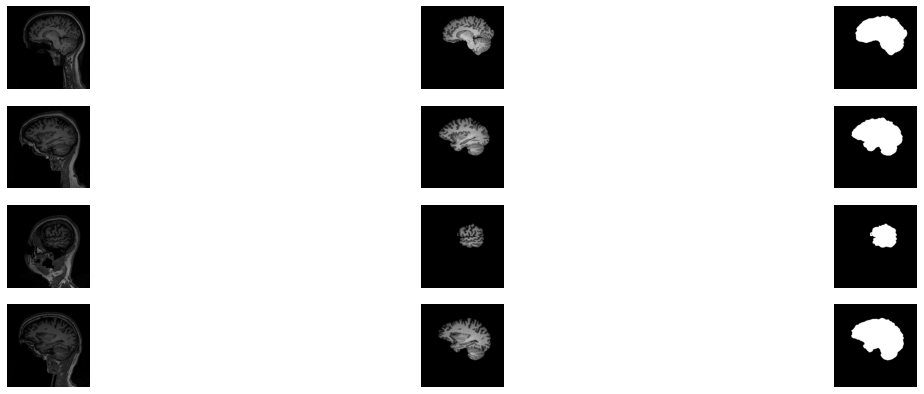

In [4]:
# Visulaize to make sure correctness of ...
plt.figure (figsize = (21,7))
for i in range(4):
    imgs=glob(f'{train_dirs[i]}/*')
    for j in range(3):
        img=cv2.imread(imgs[j])
        plt.subplot(4, 3, 3*i+j+1)
        plt.imshow (img, cmap = 'bone')
        plt.axis ('off')


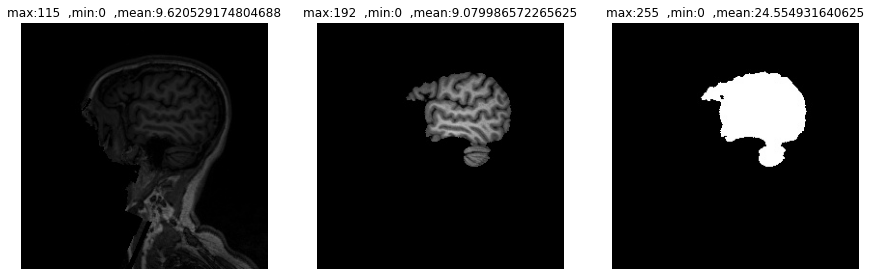

In [5]:
# Data Mean, Max, Min

imgs_path=glob(f'{train_dirs[180]}/*')
imgs=[]
for j in range(3):
    imgs.append(np.array(cv2.imread(imgs_path[j])))
imgs=np.array(imgs)

plt.figure (figsize = (15,5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow (imgs[i], cmap = 'bone')
    plt.title('max:' + str(imgs[i].max())+'  ,min:'+ str(imgs[i].min())+'  ,mean:' +str(imgs[i].mean()))
    plt.axis ('off')

(20400, 20400, 20400)

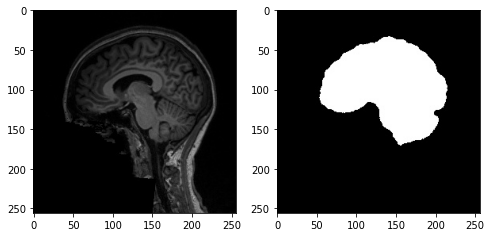

In [6]:
mm=748

train_x=[]
train_y=[]
for path in train_dirs:
    train_x.append(path+'/T1w.jpg')
    train_y.append(path+'/T1w_brainmask.jpg')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(cv2.imread(train_x[mm]))
ax2.imshow(cv2.imread(train_y[mm]))

len(train_x), len(train_y), len(train_dirs)

(3599, 3599, 3599)

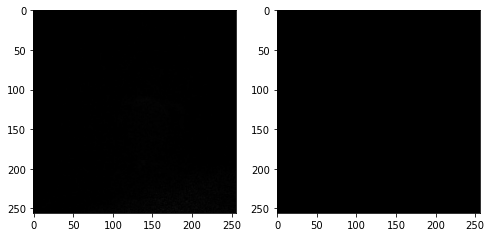

In [7]:
mm=100
val_x=[]
val_y=[]
for path in valid_dirs:
    val_x.append(path+'/T1w.jpg')
    val_y.append(path+'/T1w_brainmask.jpg')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(cv2.imread(val_x[mm]))
ax2.imshow(cv2.imread(val_y[mm]))

len(val_x), len(val_y), len(valid_dirs)

# Data Generator

In [8]:
class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, x_set, y_set=None,
                 batch_size=32,
                 img_size=(256, 256),
                 shuffle=True,
                 transform = None):
        
        self.img_paths, self.mask_paths = np.array(x_set), np.array(y_set)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.img_size = img_size        
        self.transform = transform
        
        self.on_epoch_end()

    
    def __getitem__(self, idx):
        batch_img = self.img_paths[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_mask = self.mask_paths[idx * self.batch_size:(idx + 1) * self.batch_size]
        
        x = np.array([cv2.resize(cv2.imread(p, cv2.IMREAD_GRAYSCALE), self.img_size) for p in batch_img])
        y = np.array([cv2.resize(cv2.imread(p, cv2.IMREAD_GRAYSCALE), self.img_size) for p in batch_mask])

        if self.transform is not None:
            augmented = self.transform(image= x, mask= y)
            image = augmented ['image']
            mask = augmented ['mask']
        
        return image.astype(np.float32)/255., mask.astype(np.float32)/255.
    
    def on_epoch_end(self):
        if self.shuffle:
            indices = np.random.permutation(len(self.img_paths)).astype(np.int)
            self.img_paths, self.mask_paths = self.img_paths[indices], self.mask_paths[indices]
    def __len__(self):
        return math.ceil(len(self.img_paths) / self.batch_size)

In [9]:
augmentation_p=0.6
train_transform=A.Compose([
#             A.Resize (height = 256, width = 256),
            A.VerticalFlip(p=0.5),
            A.HorizontalFlip(p=0.5),
#             A.Normalize (0.5, 0.5, max_pixel_value = 255.0),
        ], p=augmentation_p)
val_transform=A.Compose([
#             A.Resize (height = 256, width = 256),
            A.VerticalFlip(p=0.5),
            A.HorizontalFlip(p=0.5),
#             A.Normalize (0.5, 0.5, max_pixel_value = 255.0),
        ], p=augmentation_p)

In [10]:
batch_size=32
val_gen=DataGenerator(x_set=val_x , y_set=val_y , transform=train_transform, batch_size=batch_size)
train_gen=DataGenerator(x_set=train_x , y_set=train_y , transform=val_transform, batch_size=batch_size)

# Visualize && Analysis Data

In [11]:
image, mask=train_gen.__getitem__(10)
image.shape, mask.shape, type(mask), type(mask[0][0][0]), type(image), type(image[0][0][0])

((32, 256, 256),
 (32, 256, 256),
 numpy.ndarray,
 numpy.float32,
 numpy.ndarray,
 numpy.float32)

In [12]:
image.max(), image.min(), image.mean(), mask.max(), mask.min(),  mask.mean()

(0.92156863, 0.0, 0.04743727, 1.0, 0.0, 0.08098719)

<Figure size 720x360 with 0 Axes>

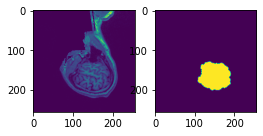

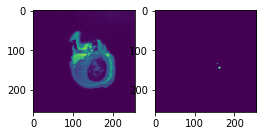

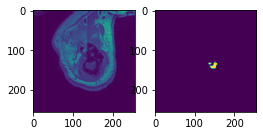

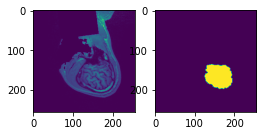

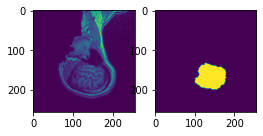

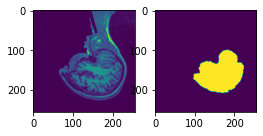

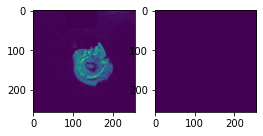

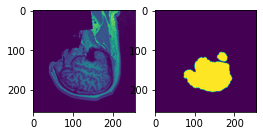

In [13]:
plt.figure (figsize = (10,5))
for i in range(8):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(4, 2))
    ax1.imshow(image[i])
    ax2.imshow(mask[i])
    plt.show()


# Loss Function

In [14]:
def iou_coef(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(K.abs(y_true_f * y_pred_f))
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    iou = K.mean((intersection + smooth) / (union + smooth))
    return iou

def dice_coef(y_true, y_pred, smooth=1.):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f + y_pred_f)
    score = (2. * intersection + smooth) / (union + smooth)
    return score

def dice_coef_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    loss = binary_crossentropy(y_true, y_pred) + dice_coef_loss(y_true, y_pred)
    return loss


In [15]:
def get_unet_128(input_shape=(None, None,1),
                 num_classes=1):
    #This U-Net implementation is derived from: 	https://github.com/petrosgk/Kaggle-Carvana-Image-Masking-Challenge
    
    inputs = Input(shape=input_shape)
    # 256

    down0 = Conv2D(32, (3, 3), padding='same')(inputs)
    down0 = BatchNormalization()(down0)
    down0 = Activation('relu')(down0)
    down0 = Conv2D(32, (3, 3), padding='same')(down0)
    down0 = BatchNormalization()(down0)
    down0 = Activation('relu')(down0)
    down0_pool = MaxPooling2D((2, 2), strides=(2, 2))(down0)
    # 128

    down1 = Conv2D(64, (3, 3), padding='same')(down0_pool)
    down1 = BatchNormalization()(down1)
    down1 = Activation('relu')(down1)
    down1 = Conv2D(64, (3, 3), padding='same')(down1)
    down1 = BatchNormalization()(down1)
    down1 = Activation('relu')(down1)
    down1_pool = MaxPooling2D((2, 2), strides=(2, 2))(down1)
    # 64

    down2 = Conv2D(128, (3, 3), padding='same')(down1_pool)
    down2 = BatchNormalization()(down2)
    down2 = Activation('relu')(down2)
    down2 = Conv2D(128, (3, 3), padding='same')(down2)
    down2 = BatchNormalization()(down2)
    down2 = Activation('relu')(down2)
    down2_pool = MaxPooling2D((2, 2), strides=(2, 2))(down2)
    # 32

    down3 = Conv2D(256, (3, 3), padding='same')(down2_pool)
    down3 = BatchNormalization()(down3)
    down3 = Activation('relu')(down3)
    down3 = Conv2D(256, (3, 3), padding='same')(down3)
    down3 = BatchNormalization()(down3)
    down3 = Activation('relu')(down3)
    down3_pool = MaxPooling2D((2, 2), strides=(2, 2))(down3)
    # 16

    down4 = Conv2D(512, (3, 3), padding='same')(down3_pool)
    down4 = BatchNormalization()(down4)
    down4 = Activation('relu')(down4)
    down4 = Conv2D(512, (3, 3), padding='same')(down4)
    down4 = BatchNormalization()(down4)
    down4 = Activation('relu')(down4)
    down4_pool = MaxPooling2D((2, 2), strides=(2, 2))(down4)
    # 8

    center = Conv2D(1024, (3, 3), padding='same')(down4_pool)
    center = BatchNormalization()(center)
    center = Activation('relu')(center)
    center = Conv2D(1024, (3, 3), padding='same')(center)
    center = BatchNormalization()(center)
    center = Activation('relu')(center)
    # center

    up4 = UpSampling2D((2, 2))(center)
    up4 = concatenate([down4, up4], axis=3)
    up4 = Conv2D(512, (3, 3), padding='same')(up4)
    up4 = BatchNormalization()(up4)
    up4 = Activation('relu')(up4)
    up4 = Conv2D(512, (3, 3), padding='same')(up4)
    up4 = BatchNormalization()(up4)
    up4 = Activation('relu')(up4)
    up4 = Conv2D(512, (3, 3), padding='same')(up4)
    up4 = BatchNormalization()(up4)
    up4 = Activation('relu')(up4)
    # 16

    up3 = UpSampling2D((2, 2))(up4)
    up3 = concatenate([down3, up3], axis=3)
    up3 = Conv2D(256, (3, 3), padding='same')(up3)
    up3 = BatchNormalization()(up3)
    up3 = Activation('relu')(up3)
    up3 = Conv2D(256, (3, 3), padding='same')(up3)
    up3 = BatchNormalization()(up3)
    up3 = Activation('relu')(up3)
    up3 = Conv2D(256, (3, 3), padding='same')(up3)
    up3 = BatchNormalization()(up3)
    up3 = Activation('relu')(up3)
    # 32

    up2 = UpSampling2D((2, 2))(up3)
    up2 = concatenate([down2, up2], axis=3)
    up2 = Conv2D(128, (3, 3), padding='same')(up2)
    up2 = BatchNormalization()(up2)
    up2 = Activation('relu')(up2)
    up2 = Conv2D(128, (3, 3), padding='same')(up2)
    up2 = BatchNormalization()(up2)
    up2 = Activation('relu')(up2)
    up2 = Conv2D(128, (3, 3), padding='same')(up2)
    up2 = BatchNormalization()(up2)
    up2 = Activation('relu')(up2)
    # 64

    up1 = UpSampling2D((2, 2))(up2)
    up1 = concatenate([down1, up1], axis=3)
    up1 = Conv2D(64, (3, 3), padding='same')(up1)
    up1 = BatchNormalization()(up1)
    up1 = Activation('relu')(up1)
    up1 = Conv2D(64, (3, 3), padding='same')(up1)
    up1 = BatchNormalization()(up1)
    up1 = Activation('relu')(up1)
    up1 = Conv2D(64, (3, 3), padding='same')(up1)
    up1 = BatchNormalization()(up1)
    up1 = Activation('relu')(up1)
    # 128

    up0 = UpSampling2D((2, 2))(up1)
    up0 = concatenate([down0, up0], axis=3)
    up0 = Conv2D(32, (3, 3), padding='same')(up0)
    up0 = BatchNormalization()(up0)
    up0 = Activation('relu')(up0)
    up0 = Conv2D(32, (3, 3), padding='same')(up0)
    up0 = BatchNormalization()(up0)
    up0 = Activation('relu')(up0)
    up0 = Conv2D(32, (3, 3), padding='same')(up0)
    up0 = BatchNormalization()(up0)
    up0 = Activation('relu')(up0)
    # 256

    classify = Conv2D(num_classes, (1, 1), activation='sigmoid')(up0)

    model = Model(inputs=inputs, outputs=classify)


    return model


In [16]:
callbacks = [
     ReduceLROnPlateau(monitor='val_loss',
          factor=0.7,  # new_lr = lr * factor
          patience=3,  # number of epochs with no improvment
          min_lr=1e-6,  # lower bound on the learning rate
          mode='min',
          verbose=1
          ),
    ModelCheckpoint(filepath='./unet_model{}.h5'.format(time()),
         monitor='val_loss',
         save_best_only=True,
         mode='min',
         # save_weights_only=save_weights_only,
         ),
    CSVLogger('training.log', separator=',', append=False)

]

In [17]:
epochs = 15
learning_rate = 0.005
loss = bce_dice_loss
multiprocessing= True
workers= 4
opt = Adam(learning_rate=learning_rate)

model=get_unet_128()
model.summary()
model.compile(optimizer=opt, loss=loss, metrics=['acc', dice_coef, iou_coef])

history = model.fit(train_gen, batch_size=batch_size, epochs=epochs, steps_per_epoch=len(train_gen),
                    validation_data=val_gen,validation_batch_size=batch_size, validation_steps=len(val_gen),
                    callbacks=callbacks, use_multiprocessing=multiprocessing, workers=workers)

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, None, None,  0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, None, None, 3 320         input_1[0][0]                    
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, None, None, 3 128         conv2d[0][0]                     
__________________________________________________________________________________________________
activation (Activation)         (None, None, None, 3 0           batch_normalization[0][0]        
______________________________________________________________________________________________

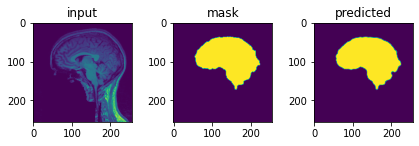

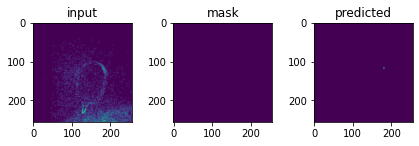

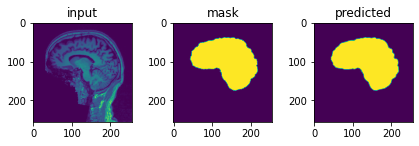

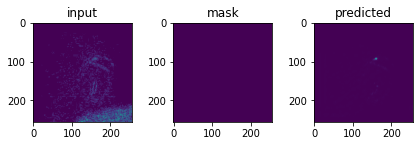

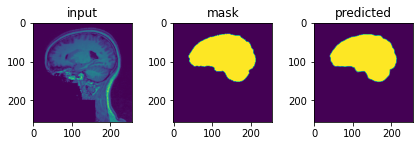

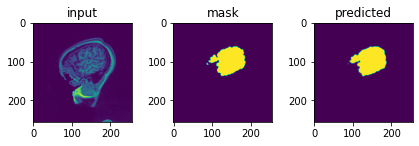

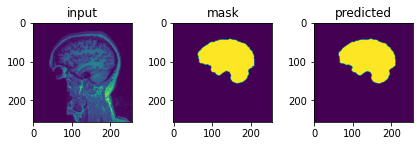

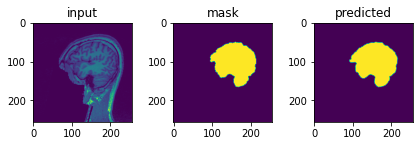

In [18]:
def get_plots(model, val_loader):
    x, y = val_loader.__getitem__(2)
    y_pre = model.predict(x)

    for i in range(int(x.shape[0]/4)):
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
        fig.tight_layout()
        ax1.imshow(x[i])
        ax1.set_title('input')
        ax2.imshow(y[i])
        ax2.set_title('mask')
        ax3.imshow(np.squeeze(y_pre[i]))
        ax3.set_title('predicted')
get_plots(model, val_gen)

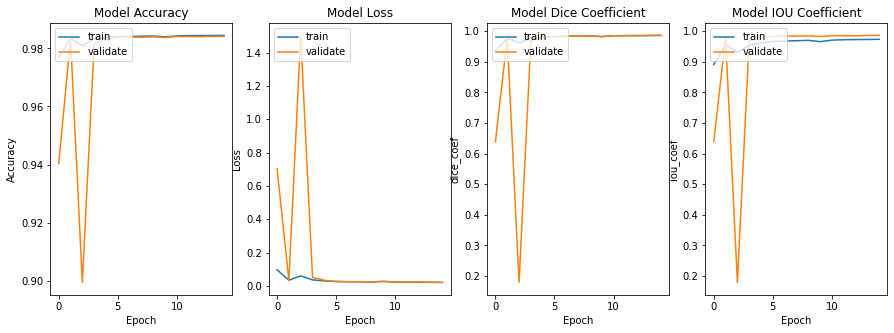

In [19]:
def plot_history(history): 
    fig, axs = plt.subplots(1,4,figsize=(15,5)) 

    epochs = len(history.history['acc'])
    
    axs[0].plot(history.history['acc']) 
    axs[0].plot(history.history['val_acc']) 
    axs[0].set_title('Model Accuracy')
    axs[0].set_ylabel('Accuracy') 
    axs[0].set_xlabel('Epoch')
    axs[0].legend(['train', 'validate'], loc='upper left')
    
    axs[1].plot(history.history['loss']) 
    axs[1].plot(history.history['val_loss']) 
    axs[1].set_title('Model Loss')
    axs[1].set_ylabel('Loss') 
    axs[1].set_xlabel('Epoch')
    axs[1].legend(['train', 'validate'], loc='upper left')
    
    axs[2].plot(history.history['dice_coef']) 
    axs[2].plot(history.history['val_dice_coef']) 
    axs[2].set_title('Model Dice Coefficient')
    axs[2].set_ylabel('dice_coef') 
    axs[2].set_xlabel('Epoch')
    axs[2].legend(['train', 'validate'], loc='upper left')

    axs[3].plot(history.history['iou_coef']) 
    axs[3].plot(history.history['val_dice_coef']) 
    axs[3].set_title('Model IOU Coefficient')
    axs[3].set_ylabel('iou_coef') 
    axs[3].set_xlabel('Epoch')
    axs[3].legend(['train', 'validate'], loc='upper left')

    plt.show()

# history = pd.read_csv(TRAINING_LOG_PATH, sep=',', engine='python')
plot_history(history)

In [20]:
!pip install --upgrade scipy

     |████████████████████████████████| 38.1 MB 3.0 MB/s            
  Attempting uninstall: scipy
    Found existing installation: scipy 1.7.2
    Uninstalling scipy-1.7.2:
      Successfully uninstalled scipy-1.7.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pdpbox 0.2.1 requires matplotlib==3.1.1, but you have matplotlib 3.5.0 which is incompatible.
imbalanced-learn 0.8.1 requires scikit-learn>=0.24, but you have scikit-learn 0.23.2 which is incompatible.


['/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_56.tif', '/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_8.tif', '/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_34.tif', '/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_33.tif', '/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_43.tif', '/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_39.tif', '/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_7.tif', '/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_31.tif', '/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_6.tif', '/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_38.tif']


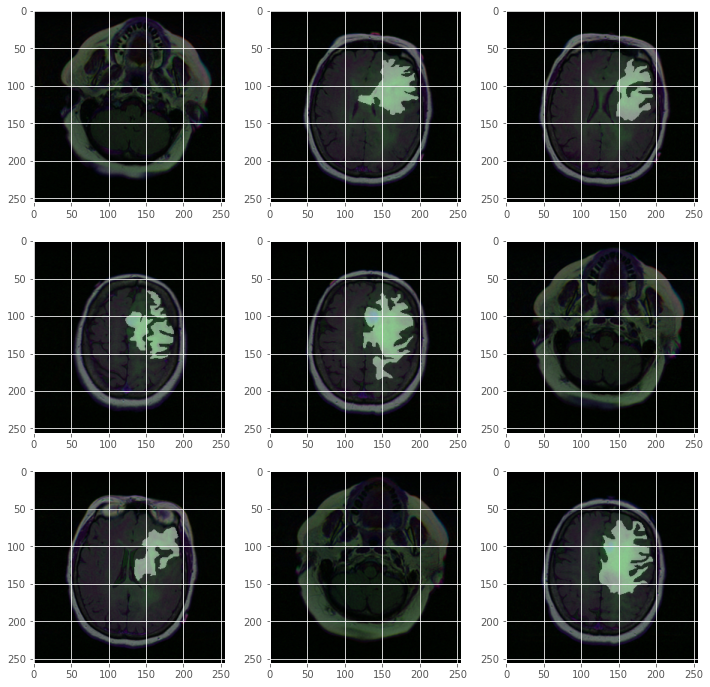

(2828, 2)
(393, 2)
(708, 2)


In [21]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")
%matplotlib inline

import cv2
from tqdm import tqdm_notebook, tnrange
from glob import glob
from itertools import chain
from skimage.io import imread, imshow, concatenate_images
from skimage.transform import resize
from skimage.morphology import label
from sklearn.model_selection import train_test_split

import tensorflow as tf
from skimage.color import rgb2gray
from tensorflow.keras import Input
from tensorflow.keras.models import Model, load_model, save_model
from tensorflow.keras.layers import Input, Activation, BatchNormalization, Dropout, Lambda, Conv2D, Conv2DTranspose, MaxPooling2D, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Model, load_model, save_model
from tensorflow.keras.layers import (
  Input,
  Activation,
  BatchNormalization,
  Dropout,
  Lambda,
  Conv2D,
  Conv2DTranspose,
  MaxPooling2D,
  concatenate,
)
from tensorflow.keras import backend as K


# Setting size parameters of images
im_width = 256
im_height = 256


image_filenames_train = []

# creating a list of all files containing the word 'mask'
# in Local Machine
# mask_files = glob('../../input/lgg-mri-segmentation/kaggle_3m/*/*_mask*')

# in Kaggle

mask_files = glob('/kaggle/input/lgg-mri-segmentation/kaggle_3m/*/*_mask*')

for i in mask_files:
  image_filenames_train.append(i.replace('_mask', ''))

print(image_filenames_train[:10])
len(image_filenames_train)


import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras import backend as K

plt.style.use("ggplot")


def plot_from_img_path(rows, columns, list_img_path, list_mask_path):
  fig = plt.figure(figsize=(12, 12))
  for i in range(1, rows * columns + 1):
      fig.add_subplot(rows, columns, i)
      img_path = list_img_path[i]
      mask_path = list_mask_path[i]
      image = cv2.imread(img_path)
      image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
      mask = cv2.imread(mask_path)
      plt.imshow(image)
      plt.imshow(mask, alpha=0.4)
  plt.show()


def dice_coefficients(y_true, y_pred, smooth=100):
  y_true_flatten = K.flatten(y_true)
  y_pred_flatten = K.flatten(y_pred)
  #print("y_true shape:", K.int_shape(y_true))
  #print("y_pred shape:", K.int_shape(y_pred))
  intersection = K.sum(y_true_flatten * y_pred_flatten)
  union = K.sum(y_true_flatten) + K.sum(y_pred_flatten)
  return (2 * intersection + smooth) / (union + smooth)


def dice_coefficients_loss(y_true, y_pred, smooth=100):
  return -dice_coefficients(y_true, y_pred, smooth)


def iou(y_true, y_pred, smooth=100):
  y_true = K.flatten(y_true)
  y_pred = K.flatten(y_pred)

  # Getting the intersection and union separately
  intersection = K.sum(y_true * y_pred)
  union = K.sum(y_true) + K.sum(y_pred) - intersection

  return (intersection + smooth) / (union + smooth)

def jaccard_distance(y_true, y_pred):
  y_true_flatten = K.flatten(y_true)
  y_pred_flatten = K.flatten(y_pred)
  return -iou(y_true_flatten, y_pred_flatten)


plot_from_img_path(3, 3 , image_filenames_train, mask_files )


df = pd.DataFrame(data={'image_filenames_train': image_filenames_train, 'mask': mask_files })

df_train, df_test = train_test_split(df, test_size=0.1)

# Further split this val and train
df_train, df_val = train_test_split(df_train, test_size=0.2)

print(df_train.shape)
print(df_test.shape)
print(df_val.shape)


def train_generator(
  data_frame,
  batch_size,
  augmentation_dict,
  image_color_mode="rgb",
  mask_color_mode="grayscale",
  image_save_prefix="image",
  mask_save_prefix="mask",
  save_to_dir=None,
  target_size=(256, 256),
  seed=1,
):

  image_datagen = ImageDataGenerator(**augmentation_dict)
  mask_datagen = ImageDataGenerator(**augmentation_dict)

  image_generator = image_datagen.flow_from_dataframe(
      data_frame,
      x_col="image_filenames_train",
      class_mode=None,
      color_mode=image_color_mode,
      target_size=target_size,
      batch_size=batch_size,
      save_to_dir=save_to_dir,
      save_prefix=image_save_prefix,
      seed=seed,
  )

  mask_generator = mask_datagen.flow_from_dataframe(
      data_frame,
      x_col="mask",
      class_mode=None,
      color_mode=mask_color_mode,
      target_size=target_size,
      batch_size=batch_size,
      save_to_dir=save_to_dir,
      save_prefix=mask_save_prefix,
      seed=seed,
  )

  train_gen = zip(image_generator, mask_generator)

  # Final return Tuple after image Normalization and Diagnostics
  for (img, mask) in train_gen:
      img, mask = normalize_and_diagnose(img, mask)
      yield (img, mask)


def normalize_and_diagnose(img, mask):
  img = img / 255
  mask = mask / 255
  mask[mask > 0.5] = 1
  mask[mask <= 0.5] = 0
  #print("Image Shape in generator:", img.shape)
  #print("Mask Shape in generator:", mask.shape)
  return(img, mask)


EPOCHS = 2
BATCH_SIZE = 32
learning_rate = 1e-4
smooth=100

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryAccuracy

train_generator_param = dict(rotation_range=0.2,
                          width_shift_range=0.2,
                          height_shift_range=0.2,
                          shear_range=0.1,
                          zoom_range=0.1,
                          horizontal_flip=True,
                          fill_mode='nearest')

train_gen = train_generator(df_train, BATCH_SIZE,
                              train_generator_param,
                              target_size=(im_height, im_width))

test_gen = train_generator(df_val, BATCH_SIZE,
                              dict(),
                              target_size=(im_height, im_width))

In [22]:
from tensorflow.keras.layers import BatchNormalization, Conv2D
from tensorflow.keras.applications import ResNet50

def build_model_with_batch_norm_and_reg(input_size=(256, 256, 3), dropout_rate=0.5, l2_reg=1e-4):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_size)

    # Encoder
    encoder_layers = [base_model.get_layer('conv1_relu').output,
                      base_model.get_layer('conv2_block3_out').output,
                      base_model.get_layer('conv3_block4_out').output,
                      base_model.get_layer('conv4_block6_out').output,
                      base_model.get_layer('conv5_block3_out').output]

    # Decoder
    x = encoder_layers[-1]
    for layer in reversed(encoder_layers[:-1]):
        x = concatenate([Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(x), layer])
        x = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
        x = BatchNormalization()(x)
        x = Dropout(dropout_rate)(x)
        x = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
        x = BatchNormalization()(x)
        x = Dropout(dropout_rate)(x)

    x = Conv2DTranspose(1, (2, 2), strides=(2, 2), padding='same')(x)
    x = Conv2D(1, (1, 1), activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=x)
    return model





#mobailnet.summary()



base_model_resnet50 = build_model_with_batch_norm_and_reg(input_size=(im_height, im_width, 3))
print(" output_shape:", base_model_resnet50.output_shape)
from tensorflow.keras.callbacks import LearningRateScheduler
def lr_schedule(epoch):
    return 1e-4 * (0.9 ** epoch)
base_model_resnet50.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss=dice_coefficients_loss, metrics=[BinaryAccuracy(), iou, dice_coefficients])
#BATCH_SIZE =16
# Ensure this line is correctly indented
callbacks = [ModelCheckpoint('resnet-50.h5', verbose=1, save_best_only=True, monitor='val_dice_coefficients', mode='max')]

history_base_model_resnet50 = base_model_resnet50.fit(
    train_gen,
    steps_per_epoch=len(df_train) / BATCH_SIZE,
    epochs=150,
    callbacks=callbacks,
    validation_data=test_gen,
    validation_steps=len(df_val) / BATCH_SIZE
)


94781440/94765736 [==============================] - 1s 0us/step
 output_shape: (None, 256, 256, 1)
Found 2828 validated image filenames.
Found 2828 validated image filenames.
Epoch 1/150
89/88 [==============================] - ETA: 0s - loss: 0.1354 - binary_accuracy: 0.7419 - iou: 0.0268 - dice_coefficients: 0.0519Found 708 validated image filenames.
Found 708 validated image filenames.
88/88 [==============================] - 169s 2s/step - loss: 0.1354 - binary_accuracy: 0.7419 - iou: 0.0268 - dice_coefficients: 0.0519 - val_loss: 0.1057 - val_binary_accuracy: 0.1273 - val_iou: 0.0125 - val_dice_coefficients: 0.0246

Epoch 00001: val_dice_coefficients improved from -inf to 0.02459, saving model to resnet-50.h5


/opt/conda/lib/python3.7/site-packages/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)


Epoch 2/150
88/88 [==============================] - 124s 1s/step - loss: 0.0134 - binary_accuracy: 0.8681 - iou: 0.0423 - dice_coefficients: 0.0807 - val_loss: 0.0421 - val_binary_accuracy: 0.1388 - val_iou: 0.0126 - val_dice_coefficients: 0.0249

Epoch 00002: val_dice_coefficients improved from 0.02459 to 0.02488, saving model to resnet-50.h5
Epoch 3/150
88/88 [==============================] - 125s 1s/step - loss: -0.0617 - binary_accuracy: 0.9081 - iou: 0.0601 - dice_coefficients: 0.1126 - val_loss: 0.0300 - val_binary_accuracy: 0.9895 - val_iou: 0.0066 - val_dice_coefficients: 0.0091

Epoch 00003: val_dice_coefficients did not improve from 0.02488
Epoch 4/150
88/88 [==============================] - 126s 1s/step - loss: -0.1212 - binary_accuracy: 0.9343 - iou: 0.0838 - dice_coefficients: 0.1531 - val_loss: 0.0182 - val_binary_accuracy: 0.9887 - val_iou: 0.0064 - val_dice_coefficients: 0.0083

Epoch 00004: val_dice_coefficients did not improve from 0.02488
Epoch 5/150
88/88 [======

In [23]:

best_model = load_model('/kaggle/input/unet-resnet50/resnet50.h5', custom_objects={
   'dice_coefficients_loss': dice_coefficients_loss,
   'iou': iou,
   'dice_coefficients': dice_coefficients
})

# Now, you can evaluate the model
final_results_best_model = best_model.evaluate(test_gen, steps=len(df_val) / BATCH_SIZE)

# Print the final results
print("Final Loss (Best Model):", final_results_best_model[0])
print("Final Binary Accuracy (Best Model):", final_results_best_model[1])
print("Final IoU (Best Model):", final_results_best_model[2])
print("Final Dice Coefficients (Best Model):", final_results_best_model[3])


22/22 [==============================] - 10s 399ms/step - loss: -0.9201 - binary_accuracy: 0.9984 - iou: 0.8675 - dice_coefficients: 0.9283
Final Loss (Best Model): -0.9201471209526062
Final Binary Accuracy (Best Model): 0.9984403252601624
Final IoU (Best Model): 0.8675462603569031
Final Dice Coefficients (Best Model): 0.9283168911933899
